<a href="https://colab.research.google.com/github/shantanushendarkar27/demo-2/blob/main/PDS(EX9).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



*   Name : Shantanu Santosh Shendarkar
*   Branch : AI&DS

*  Roll No : SY B 42

*  Batch : SY B3





Aim

To build a simple Data Science pipeline by combining all the techniques learned in previous labs into one complete process.

Introduction

In real life, data does not come in a clean and ready-to-use form. Before using it for predictions or analysis, we need to process it step by step. This complete process is called a Data Science Pipeline. It helps us move from raw data to useful insights in a structured and organized way.

1. What is a Data Science Pipeline? Explain its Key Stages

A Data Science pipeline is simply a series of steps used to solve a data-related problem.

Main Stages:
Data Collection:
First, we gather data from different sources like websites, databases, or surveys.
Example: Collecting customer purchase data.
Data Cleaning:
The collected data may have missing values or errors, so we clean it.
Example: Filling missing values or removing duplicates.
Exploratory Data Analysis (EDA):
Here, we study the data using graphs and statistics to understand patterns.
Example: Checking how sales change over time.
Feature Engineering:
We create new useful features from existing data.
Example: Calculating total price from quantity and cost.
Model Building:
A machine learning model is created to make predictions.
Example: Predicting house prices.
Evaluation:
We check how well the model performs.
Example: Using accuracy or error values.
Deployment:
Finally, the model is used in real applications.
Example: Recommendation systems in apps.
2. What is Exploratory Data Analysis (EDA)?

EDA is the process of understanding the data before using it. It helps us find patterns, errors, and relationships.

Types of EDA:
Univariate Analysis:
It studies only one variable at a time.
Example: Finding the average marks of students.
Bivariate Analysis:
It studies the relationship between two variables.
Example: Study hours vs marks.



3. Difference between Label Encoding and One-Hot Encoding
Label Encoding:
Converts categories into numbers.
Example: Red = 0, Blue = 1, Green = 2
It is useful when there is an order in data.
One-Hot Encoding:
Converts categories into separate columns with 0 and 1 values.
Example: Red → (1,0,0)
It is used when there is no order.



Label Encoding → Single column
One-Hot Encoding → Multiple columns
4. Why is Feature Scaling Required?

Different features can have different ranges, which may affect the model.

Example:

Age = 20–50
Salary = 10,000–1,00,000

In this case, salary values dominate. So, we scale the data.

Types:
Normalization:
Converts values between 0 and 1.
Standardization:
Converts data so that mean = 0 and standard deviation = 1.



5. What is Feature Engineering?

Feature engineering means creating new useful features from existing data.

Examples:
Extracting day or month from a date
Calculating total cost
Grouping data into categories



Initial Dataset Preview:
    survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Dataset Shape: (891, 15)

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
--

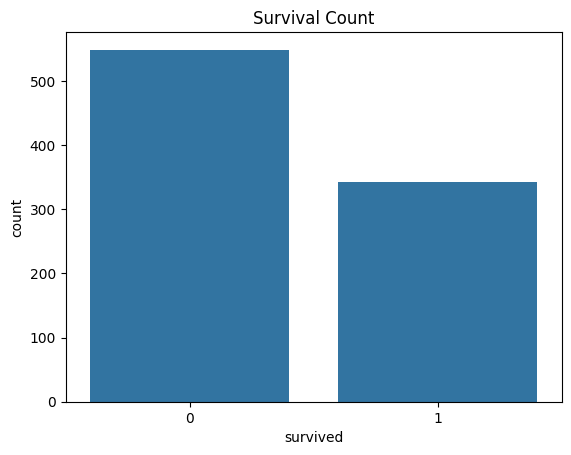

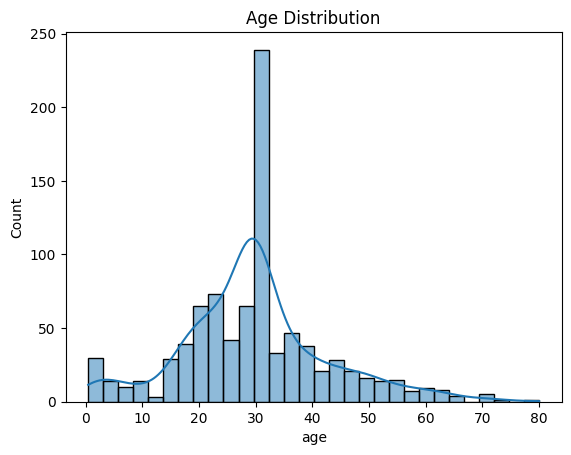

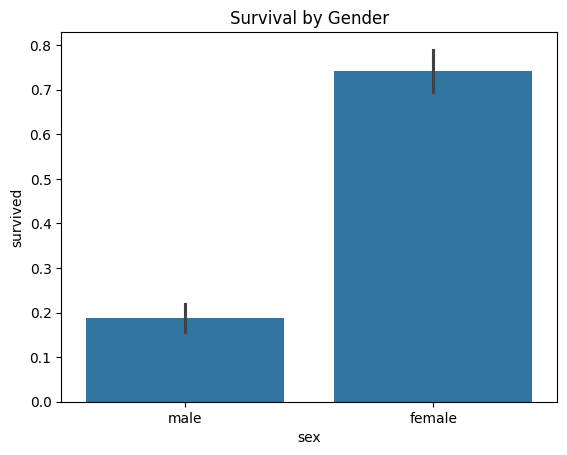

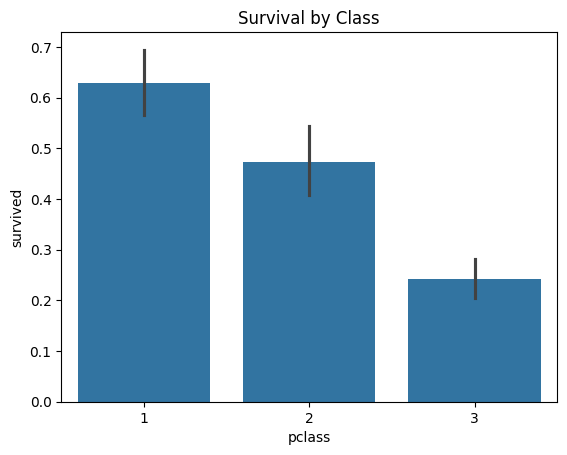


--- Logistic Regression Results ---
Accuracy: 0.8268156424581006
Confusion Matrix:
 [[101   9]
 [ 22  47]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.92      0.87       110
           1       0.84      0.68      0.75        69

    accuracy                           0.83       179
   macro avg       0.83      0.80      0.81       179
weighted avg       0.83      0.83      0.82       179


--- Decision Tree Results ---
Accuracy: 0.7597765363128491
Confusion Matrix:
 [[96 14]
 [29 40]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.87      0.82       110
           1       0.74      0.58      0.65        69

    accuracy                           0.76       179
   macro avg       0.75      0.73      0.73       179
weighted avg       0.76      0.76      0.75       179


Cross-validation Scores: [0.77094972 0.79213483 0.80337079 0.78089888 0.83146067]
Mean CV A

In [ ]:
# ============================================================
# FINAL EXPERIMENT: COMPLETE DATA SCIENCE PIPELINE
# Dataset: Titanic (Seaborn)
# ============================================================

# -------------------- STEP 1: IMPORT LIBRARIES --------------------
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')


# -------------------- STEP 2: LOAD DATA --------------------
df = sns.load_dataset('titanic')

print("\nInitial Dataset Preview:\n", df.head())
print("\nDataset Shape:", df.shape)


# -------------------- STEP 3: DATA UNDERSTANDING --------------------
print("\nDataset Info:\n")
print(df.info())

print("\nMissing Values:\n", df.isnull().sum())


# -------------------- STEP 4: DATA CLEANING --------------------
# Drop irrelevant columns
df.drop(['deck', 'alive', 'class', 'who', 'adult_male', 'embark_town'], axis=1, inplace=True)

# Handle missing values
age_imputer = SimpleImputer(strategy='mean')
df['age'] = age_imputer.fit_transform(df[['age']])

embarked_imputer = SimpleImputer(strategy='most_frequent')
df['embarked'] = embarked_imputer.fit_transform(df[['embarked']]).ravel()

# Drop remaining missing target rows (if any)
df.dropna(subset=['survived'], inplace=True)


# -------------------- STEP 5: EXPLORATORY DATA ANALYSIS --------------------
# Univariate Analysis
sns.countplot(x='survived', data=df)
plt.title("Survival Count")
plt.show()

sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

# Bivariate Analysis
sns.barplot(x='sex', y='survived', data=df)
plt.title("Survival by Gender")
plt.show()

sns.barplot(x='pclass', y='survived', data=df)
plt.title("Survival by Class")
plt.show()


# -------------------- STEP 6: FEATURE ENGINEERING --------------------
# Create new feature
df['family_size'] = df['sibsp'] + df['parch']

# Age groups
df['age_group'] = pd.cut(df['age'],
                         bins=[0, 12, 18, 40, 60, 100],
                         labels=['Child', 'Teen', 'Adult', 'MidAge', 'Senior'])


# -------------------- STEP 7: ENCODING --------------------
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])

# One-hot encoding
df = pd.get_dummies(df, columns=['embarked', 'age_group'], drop_first=True)


# -------------------- STEP 8: FEATURE SCALING --------------------
scaler = StandardScaler()
df[['age', 'fare', 'family_size']] = scaler.fit_transform(df[['age', 'fare', 'family_size']])


# -------------------- STEP 9: DEFINE FEATURES & TARGET --------------------
X = df.drop('survived', axis=1)
y = df['survived']


# -------------------- STEP 10: TRAIN-TEST SPLIT --------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# -------------------- STEP 11: MODEL BUILDING --------------------
# Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)


# -------------------- STEP 12: EVALUATION --------------------
print("\n--- Logistic Regression Results ---")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))

print("\n--- Decision Tree Results ---")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))


# -------------------- STEP 13: CROSS-VALIDATION --------------------
cv_scores = cross_val_score(lr_model, X, y, cv=5)
print("\nCross-validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())


# -------------------- STEP 14: MODEL COMPARISON --------------------
lr_acc = accuracy_score(y_test, y_pred_lr)
dt_acc = accuracy_score(y_test, y_pred_dt)

print("\nModel Comparison:")
print("Logistic Regression Accuracy:", lr_acc)
print("Decision Tree Accuracy:", dt_acc)

best_model = "Logistic Regression" if lr_acc > dt_acc else "Decision Tree"
print("Best Model:", best_model)


# -------------------- STEP 15: FINAL PREDICTION --------------------
sample = X_test.iloc[0:1]
prediction = lr_model.predict(sample)

print("\nSample Prediction:", prediction)
print("Actual Value:", y_test.iloc[0])

# ============================================================
# END OF PIPELINE
# ============================================================

Conclusion

A Data Science pipeline helps us organize the entire workflow from raw data to final results. Each step, from data cleaning to model deployment, plays an important role. Techniques like EDA, encoding, scaling, and feature engineering make the model more effective and reliable. Understanding this process is essential for solving real-world problems using data.